imports and loading dataset

In [1]:

import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

from data_loader import load_complaints, inspect_nulls, narrative_availability, word_count_stats
from preprocessor import map_products, filter_complaints, apply_cleaning, standardise_columns, save_dataset
df = load_complaints('../data/raw/complaints.csv')

Loaded 9,609,797 rows and 18 columns from ../data/raw/complaints.csv



datatypes and nulls

In [2]:
inspect_nulls(df)

,null_count,null_%
Tags,8981029,93.46
Consumer disputed?,8841498,92.01
Consumer complaint narrative,6629041,68.98
Company public response,4770207,49.64
Consumer consent provided?,1649561,17.17
Sub-issue,839522,8.74
Sub-product,235295,2.45
State,54516,0.57
ZIP code,30228,0.31
Company response to consumer,20,0.00


product distribution analysis

Total unique products: 21


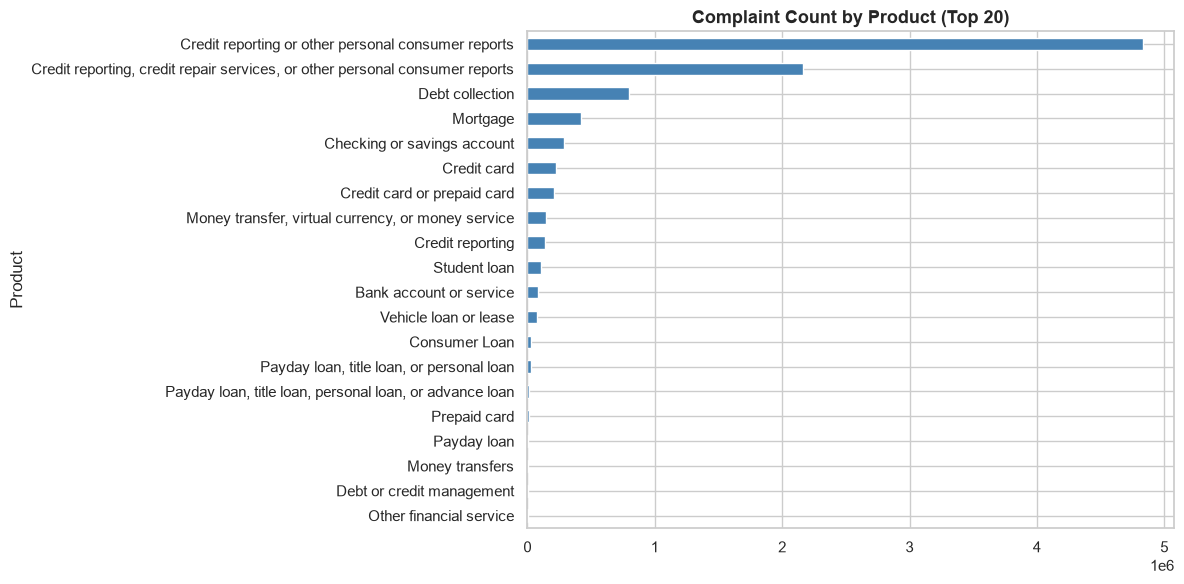

In [3]:
product_counts = df['Product'].value_counts()
print(f"Total unique products: {df['Product'].nunique()}")

fig, ax = plt.subplots(figsize=(12, 6))
product_counts.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Complaint Count by Product (Top 20)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/product_distribution.png', dpi=150)
plt.show()

narrarive avaiablity analysis
With vs without narratives

In [4]:
stats = narrative_availability(df)

With narrative   : 2,980,756  (31.0%)
Without narrative: 6,629,041  (69.0%)


narative length analysis
Word count distribution

Word count stats & plot

=== Narrative Word Count Stats ===
count    2980756.0
mean         175.6
std          225.9
min            1.0
25%           59.0
50%          114.0
75%          209.0
max         6469.0
Name: word_count, dtype: float64

Very short (<10 words) : 21,938
Very long  (>500 words): 160,989


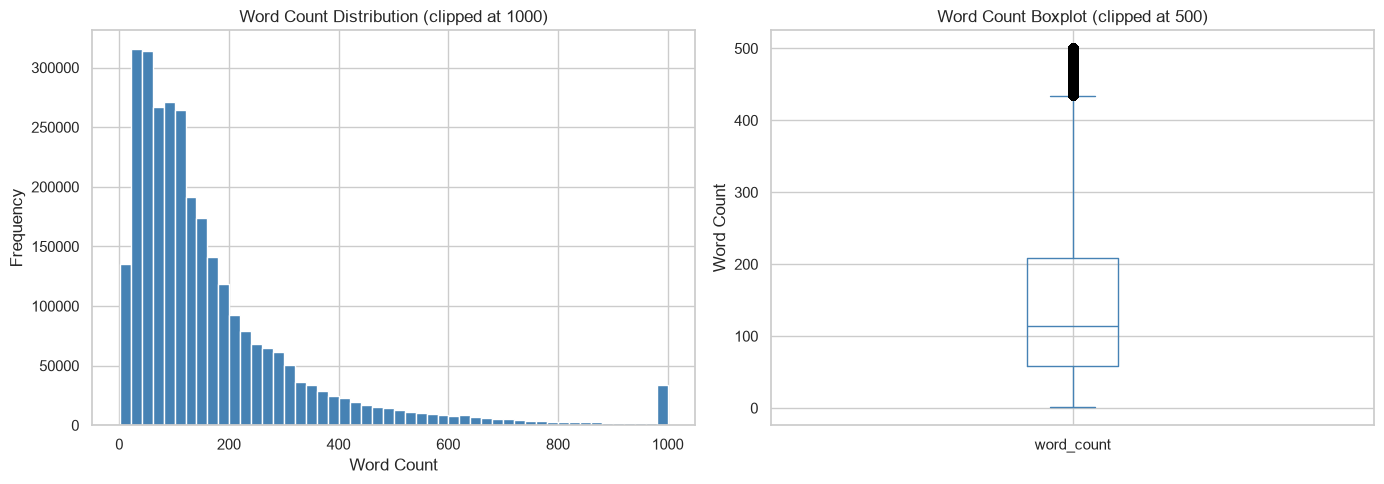

In [5]:
wc_df = word_count_stats(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc_df['word_count'].clip(upper=1000).hist(
    bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Word Count Distribution (clipped at 1000)')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

wc_df['word_count'].clip(upper=500).plot(
    kind='box', ax=axes[1], vert=True, color='steelblue')
axes[1].set_title('Word Count Boxplot (clipped at 500)')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('../data/processed/narrative_length.png', dpi=150)
plt.show()

filter and clean pipeline

In [6]:
df = map_products(df)
df = filter_complaints(df)
df = apply_cleaning(df)
df = standardise_columns(df)

Mapped product counts (including NaN = unmapped):
product_category
NaN                8662537
Savings Account     377383
Credit Card         241966
Personal Loan       177473
Money Transfer      150438
Name: count, dtype: int64
After product filter   : 947,260 rows
After narrative filter : 424,018 rows

Product distribution after filtering:
product_category
Savings Account    155204
Money Transfer      98701
Credit Card         88459
Personal Loan       81654
Name: count, dtype: int64
After cleaning: 423,913 rows remain (105 dropped — too short after cleaning)
Final shape: (423913, 9)


plot  filtered distribution

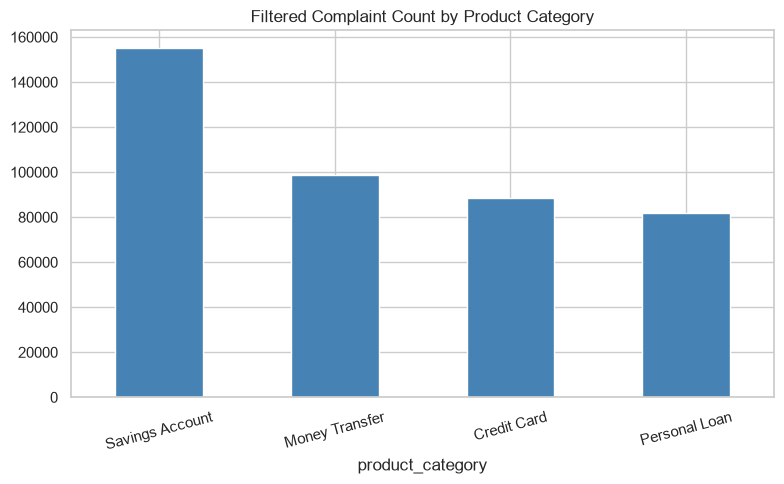

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
df['product_category'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Filtered Complaint Count by Product Category')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('../data/processed/filtered_product_distribution.png', dpi=150)
plt.show()

save the final

In [8]:
save_dataset(df)

Saved 423,913 rows to ../data/processed/filtered_complaints.csv
